## Explication de la methode:  
Ce code implémente l’algorithme G-Means, une version adaptative de K-Means qui estime automatiquement le nombre optimal de clusters. Il commence par une réduction de dimension avec PCA, puis initialise K-Means avec un seul cluster (la moyenne de toutes les données). Ensuite, chaque cluster est testé pour voir s’il suit une distribution normale à l’aide du test d’Anderson-Darling. Si ce n’est pas le cas, il est divisé en deux sous-clusters le long de l’axe de plus grande variance. Avant d’accepter cette division, l’algorithme applique une contrainte de distance minimale entre les deux nouveaux centres (0.1 par défaut) et vérifie que le score de silhouette ne diminue pas. Si ces conditions sont satisfaites, la division est conservée. Ce processus se répète jusqu’à ce qu’aucune division valide ne soit trouvée ou que le nombre maximal de clusters soit atteint. 

### SOLUTION 1: THIS FIRST CODE ONLY USES G-MEANS AND SILHOUTTE SCORE AS CONTRAINT: (SO BASICALLY SAME AS PREVIOUS ONE)

In [1]:
import numpy as np
from sklearn.cluster import KMeans
from scipy.stats import anderson
from sklearn.decomposition import PCA
from sklearn.datasets import load_iris, load_digits, load_wine, load_breast_cancer, make_blobs, make_moons, make_circles
from sklearn.metrics import silhouette_score

# def calculate_similarity(true_k, predicted_k, threshold=1):
#     """Calculate the similarity percentage based on how close true_k and predicted_k are."""
#     # If the difference between true_k and predicted_k is within the threshold, count it as a close match
#     if abs(true_k - predicted_k) <= threshold:
#         return 100  # Perfect match
#     else:
#         # You can scale this percentage for larger differences (if desired)
#         similarity = max(0, 100 - abs(true_k - predicted_k) * 10)  # 10% penalty per unit of difference
#         return similarity
def calculate_similarity(true_k, predicted_k, threshold=1):
    """Stricter similarity calculation with graduated penalties.
    
    Args:
        true_k (int): True number of clusters
        predicted_k (int): Predicted number of clusters
        threshold (int): Maximum allowed difference for full credit
        
    Returns:
        float: Similarity percentage (0-100)
    """
    difference = abs(true_k - predicted_k)
    
    if difference == 0:
        return 100  # Perfect match
    elif difference <= threshold:
        return 90 - (difference * 5)  # 90% for ±1, 85% for ±2, etc.
    else:
        # Exponential penalty for larger differences
        penalty = min(50, 10 * (difference ** 2))  # Quadratic penalty
        return max(0, 70 - penalty)  # Never goes below 20%

def g_means_simplified(X, max_k=None, random_state=42):
    # Dimensionality reduction
    n_components = max(2, min(10, int(0.9 * X.shape[1])))
    X_reduced = PCA(n_components=n_components).fit_transform(X)
    #
    # PREPROCESSING:
    # HERE ADD A FUNCTION TO DELETE ALL NON NUMERICAL DATA,
    # AND ALSO NORMALISE THE DATA BEFORE PROCESSING
    #
    if max_k is None:
        max_k = min(15, int(0.1 * len(X)))

    # Initialize with global mean
    centers = [np.mean(X_reduced, axis=0)]
    # print(centers)
    prev_silhouette = None
    currk=1
    n_iter=0
    while len(centers) < max_k:
        
        kmeans = KMeans(n_clusters=currk, init='random', n_init=10, random_state=random_state)
        labels = kmeans.fit_predict(X_reduced)
        centers = kmeans.cluster_centers_
        # print('for k= ',len(centers))
        # print(f"Number of iterations: {kmeans.n_iter_}")
        n_iter= n_iter+kmeans.n_iter_
        new_centers = []

        changed = False
        # Compute silhouette score only if k > 1
        if len(centers) > 1:
            current_silhouette = silhouette_score(X_reduced, labels)
            if prev_silhouette is not None and current_silhouette < prev_silhouette:
                break  # Stop splitting if clusters are getting worse
            prev_silhouette = current_silhouette  # Update best silhouette score
        
        for j in range(len(centers)):
            cluster_data = X_reduced[labels == j]
            min_cluster_size = max(10, int(0.02 * len(X)))
            if len(cluster_data) < min_cluster_size:
                new_centers.append(centers[j])
                continue
            # Gaussian check only (no distance constraint)
            centered = cluster_data - centers[j]
            cov = np.cov(centered.T)
            eigvals, eigvecs = np.linalg.eigh(cov)
            direction = eigvecs[:, np.argmax(eigvals)]
            projected = np.dot(centered, direction)
            standardized = (projected - np.mean(projected)) / np.std(projected)
            ad_stat = anderson(standardized).statistic
            critical = anderson(standardized).critical_values[2] * (1 + np.log(len(cluster_data)) / 10)
            
            if ad_stat > critical:
                changed = True
                currk=currk+1
                kmeans = KMeans(n_clusters=currk, init='random', n_init=10, random_state=random_state)
                labels = kmeans.fit_predict(X_reduced)
                
                temp_silhouette = silhouette_score(X_reduced, labels)
                
                if prev_silhouette is None or temp_silhouette >= prev_silhouette:
                
                    
                    prev_silhouette = temp_silhouette
                else:
                    new_centers.append(centers[j])
                
        if not changed:
            break
        centers = new_centers
    
    return len(centers), n_iter



datasets = {
    "Iris": (load_iris().data, 3),
    "Digits": (load_digits().data, 10),
    "Wine": (load_wine().data, 3),
    "Breast Cancer": (load_breast_cancer().data, 2),
    "Blobs": (make_blobs(n_samples=300, centers=4, random_state=42)[0], 4),
    "Moons": (make_moons(n_samples=300, noise=0.05, random_state=42)[0], 2),
    "Circles": (make_circles(n_samples=300, noise=0.05, factor=0.5, random_state=42)[0], 2),
}

true_k_values = []
predicted_k_values = []
dataset_names = []
number_of_iterations=[]

# Run G-Means on each dataset
for name, (X, true_k) in datasets.items():
    predicted_k, n_iter = g_means_simplified(X)
    number_of_iterations.append(n_iter)
    print(f"Dataset: {name}, True k: {true_k}, Predicted k: {predicted_k}")
    dataset_names.append(name)
    true_k_values.append(true_k)
    predicted_k_values.append(predicted_k)

similarities1 = []  # List to store the similarity percentages

# Calculate similarity for each dataset
for true_k, predicted_k, name in zip(true_k_values, predicted_k_values, dataset_names):
    similarity = calculate_similarity(true_k, predicted_k)  # Calculate similarity
    similarities1.append((name, true_k, predicted_k, similarity))

    # print(f"Dataset: {name}, True k: {true_k}, Predicted k: {predicted_k}, Similarity: {similarity}%")

# Optionally, calculate the average similarity across all datasets
average_similarity = np.mean([sim[3] for sim in similarities1])
print(f"\nAverage Similarity Across All Datasets: {average_similarity:.2f}%")
print(number_of_iterations)

Dataset: Iris, True k: 3, Predicted k: 4
Dataset: Digits, True k: 10, Predicted k: 11
Dataset: Wine, True k: 3, Predicted k: 2
Dataset: Breast Cancer, True k: 2, Predicted k: 4
Dataset: Blobs, True k: 4, Predicted k: 4
Dataset: Moons, True k: 2, Predicted k: 4
Dataset: Circles, True k: 2, Predicted k: 2

Average Similarity Across All Datasets: 73.57%
[12, 96, 9, 33, 10, 31, 9]


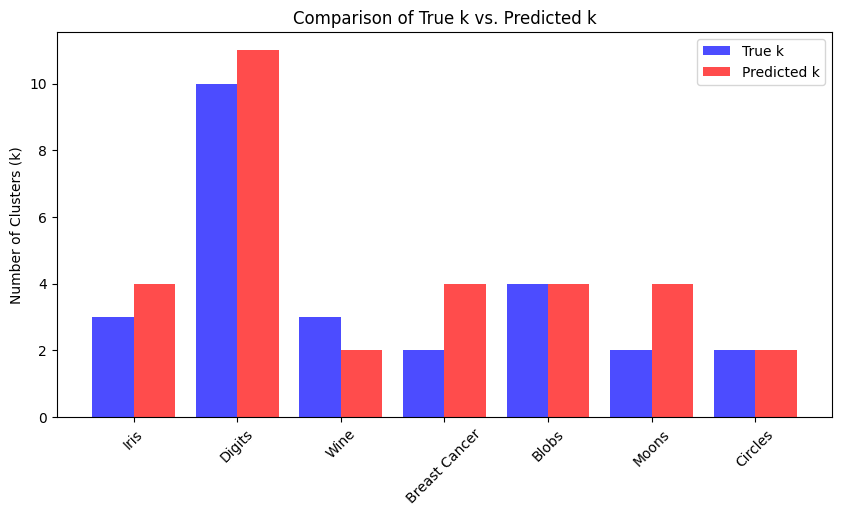


Average Similarity Across All Datasets: 73.57%
similarities1
[('Iris', 3, 4, 85), ('Digits', 10, 11, 85), ('Wine', 3, 2, 85), ('Breast Cancer', 2, 4, 30), ('Blobs', 4, 4, 100), ('Moons', 2, 4, 30), ('Circles', 2, 2, 100)]


In [2]:
import matplotlib.pyplot as plt

# Bar Chart for True k vs. Predicted k
plt.figure(figsize=(10, 5))
x = np.arange(len(dataset_names))
plt.bar(x - 0.2, true_k_values, width=0.4, label='True k', color='blue', alpha=0.7)
plt.bar(x + 0.2, predicted_k_values, width=0.4, label='Predicted k', color='red', alpha=0.7)
plt.xticks(x, dataset_names, rotation=45)
plt.ylabel("Number of Clusters (k)")
plt.title("Comparison of True k vs. Predicted k")
plt.legend()
plt.show()

    
print(f"\nAverage Similarity Across All Datasets: {average_similarity:.2f}%")
print('similarities1')
print(similarities1)

### SOLUTION 2: THIS ONE ADDS ONE THING: THE SELECTION OF THE CENTROIDS ISNT RANDOM BUT USING THE METHOD MENTIONED IN THE PAPER:

In [3]:
import numpy as np
from sklearn.cluster import KMeans
from scipy.stats import anderson
from sklearn.decomposition import PCA
from sklearn.datasets import load_iris, load_digits, load_wine, load_breast_cancer, make_blobs, make_moons, make_circles
from sklearn.metrics import silhouette_score
from sklearn.preprocessing import StandardScaler

def g_means(X, max_k=None, random_state=42):
    # X = StandardScaler().fit_transform(X)  #  Normalisation ici
    n_components = max(2, min(10, int(0.9 * X.shape[1])))  # Keep 2-10 dimensions
    X_reduced = PCA(n_components=n_components).fit_transform(X)
    
    if max_k is None:
        max_k = min(15, int(0.1 * len(X)))  # Dynamic cap

    
    centers = [np.mean(X_reduced, axis=0)]#axis=0 : the mean is calculated column-wise

    prev_silhouette = None 
    n_iter=0
    while len(centers) < max_k:
        kmeans = KMeans(n_clusters=len(centers), #specifies how many clusters the KMeans algorithm will create, initialy its =1
                        init=np.array(centers), # centers list contains the centroids of each cluster. Initially, theres only one centroid, which is the mean of the entire dataset.
                        n_init=1, #controls how many times the KMeans algorithm will run but since im providing a specific initialization with init=, no need to initialize randomly multiple times. 
                        random_state=random_state)
        labels = kmeans.fit_predict(X_reduced)
        centers = kmeans.cluster_centers_
        # print('for k= ',len(centers))
        # print(f"Number of iterations: {kmeans.n_iter_}")
        n_iter= n_iter+kmeans.n_iter_
        # Compute silhouette score only if k > 1
        if len(centers) > 1:
            current_silhouette = silhouette_score(X_reduced, labels)
            if prev_silhouette is not None and current_silhouette < prev_silhouette:
                break  # Stop splitting if clusters are getting worse
            prev_silhouette = current_silhouette  # Update best silhouette score
        
        new_centers = []
        changed = False
        # For each cluster, the algorithm attempts to split the cluster into 
        # two if it detects that the data within the cluster is not normally distributed.
        for j in range(len(centers)):
            #For each cluster (j), the data points belonging to that cluster are selected using the labels array.
            cluster_data = X_reduced[labels == j]
            #This variable defines the minimum size a cluster must have to be considered for splitting.
            min_cluster_size = max(10, int(0.02 * len(X)))
            #Skip small clusters
            if len(cluster_data) < min_cluster_size:
                new_centers.append(centers[j])
                continue
            centered = cluster_data - centers[j]
            cov = np.cov(centered.T)#The covariance matrix is computed for the centered data to understand how the data is spread along different dimensions.
            eigvals, eigvecs = np.linalg.eigh(cov)
            direction = eigvecs[:, np.argmax(eigvals)]
            projected = np.dot(centered, direction)
            standardized = (projected - np.mean(projected)) / np.std(projected)
            ad_stat = anderson(standardized).statistic
            critical = anderson(standardized).critical_values[2] * (1 + np.log(len(cluster_data)) / 10)

            if ad_stat > critical:
                #--------------------------------------
                # --- Paper's Method: Partition along axis of highest variance ---
                # 1. Sort cluster data along the highest-variance axis
                variance = np.var(cluster_data, axis=0)
                split_axis = np.argmax(variance)  # Axis with max variance
                sorted_indices = np.argsort(cluster_data[:, split_axis])
                sorted_data = cluster_data[sorted_indices]

                # 2. Compute cumulative distances along the split axis
                distances = np.diff(sorted_data[:, split_axis]) ** 2  # Squared Euclidean
                dsum = np.cumsum(distances)
                centroid_dist = np.mean(dsum)  # Paper's "centroidDist"

                # 3. Find optimal split point (m)
                split_point = np.argmin(np.abs(dsum - centroid_dist))

                # 4. Create new centroids (mean of left/right partitions)
                c1 = np.mean(sorted_data[:split_point + 1], axis=0)
                c2 = np.mean(sorted_data[split_point + 1:], axis=0)
                #-------------------------------------
               
                # 2. Temporarily test the silhouette if we did the split
                temp_centers = list(centers.copy())
                temp_centers.pop(j)  # removes the j-th cluster center by index

                temp_centers.extend([c1, c2])

                temp_kmeans = KMeans(n_clusters=len(temp_centers), init=np.array(temp_centers), n_init=1, random_state=random_state)
                temp_labels = temp_kmeans.fit_predict(X_reduced)
                temp_silhouette = silhouette_score(X_reduced, temp_labels)

                if (prev_silhouette is None or temp_silhouette >= prev_silhouette):
                    new_centers.extend([c1, c2])
                    changed = True
                    prev_silhouette = temp_silhouette
                else:
                    new_centers.append(centers[j])
            else:
                new_centers.append(centers[j])
        # If no new centers were added after trying to split the clusters, the algorithm stops.
        if not changed:
            break
        centers = new_centers
    
    # Final result
    return len(centers), n_iter


# Predefined datasets and their expected cluster counts
datasets = {
    "Iris": (load_iris().data, 3),
    "Digits": (load_digits().data, 10),
    "Wine": (load_wine().data, 3),
    "Breast Cancer": (load_breast_cancer().data, 2),
    "Blobs": (make_blobs(n_samples=300, centers=4, random_state=42)[0], 4),
    "Moons": (make_moons(n_samples=300, noise=0.05, random_state=42)[0], 2),
    "Circles": (make_circles(n_samples=300, noise=0.05, factor=0.5, random_state=42)[0], 2),
}

true_k_values = []
predicted_k_values = []
dataset_names = []
number_of_iterations=[]

# Run G-Means on each dataset
for name, (X, true_k) in datasets.items():
    predicted_k, n_iter = g_means(X)
    number_of_iterations.append(n_iter)
    print(f"Dataset: {name}, True k: {true_k}, Predicted k: {predicted_k}")
    dataset_names.append(name)
    true_k_values.append(true_k)
    predicted_k_values.append(predicted_k)


print(number_of_iterations)

Dataset: Iris, True k: 3, Predicted k: 2
Dataset: Digits, True k: 10, Predicted k: 10
Dataset: Wine, True k: 3, Predicted k: 2
Dataset: Breast Cancer, True k: 2, Predicted k: 2
Dataset: Blobs, True k: 4, Predicted k: 4
Dataset: Moons, True k: 2, Predicted k: 2
Dataset: Circles, True k: 2, Predicted k: 3
[4, 95, 6, 8, 5, 4, 10]


### Mesure de perfermance de mon algorithm:  

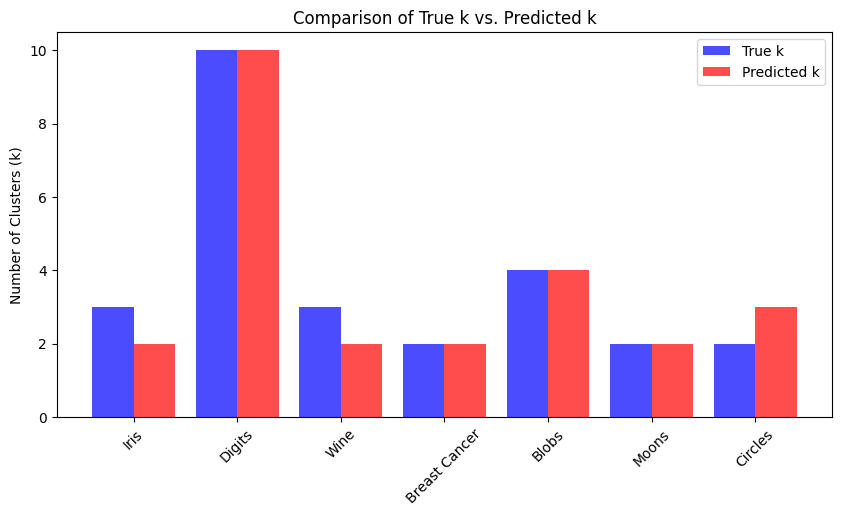


Average Similarity Across All Datasets: 93.57%
similarities2
[('Iris', 3, 2, 85), ('Digits', 10, 10, 100), ('Wine', 3, 2, 85), ('Breast Cancer', 2, 2, 100), ('Blobs', 4, 4, 100), ('Moons', 2, 2, 100), ('Circles', 2, 3, 85)]


In [4]:
import matplotlib.pyplot as plt

# Bar Chart for True k vs. Predicted k
plt.figure(figsize=(10, 5))
x = np.arange(len(dataset_names))
plt.bar(x - 0.2, true_k_values, width=0.4, label='True k', color='blue', alpha=0.7)
plt.bar(x + 0.2, predicted_k_values, width=0.4, label='Predicted k', color='red', alpha=0.7)
plt.xticks(x, dataset_names, rotation=45)
plt.ylabel("Number of Clusters (k)")
plt.title("Comparison of True k vs. Predicted k")
plt.legend()
plt.show()

    
similarities2 = []  # List to store the similarity percentages

# Calculate similarity for each dataset
for true_k, predicted_k, name in zip(true_k_values, predicted_k_values, dataset_names):
    similarity = calculate_similarity(true_k, predicted_k)  # Calculate similarity
    similarities2.append((name, true_k, predicted_k, similarity))

    # print(f"Dataset: {name}, True k: {true_k}, Predicted k: {predicted_k}, Similarity: {similarity}%")
average_similarity = np.mean([sim[3] for sim in similarities2])
print(f"\nAverage Similarity Across All Datasets: {average_similarity:.2f}%")

print('similarities2')
print(similarities2)

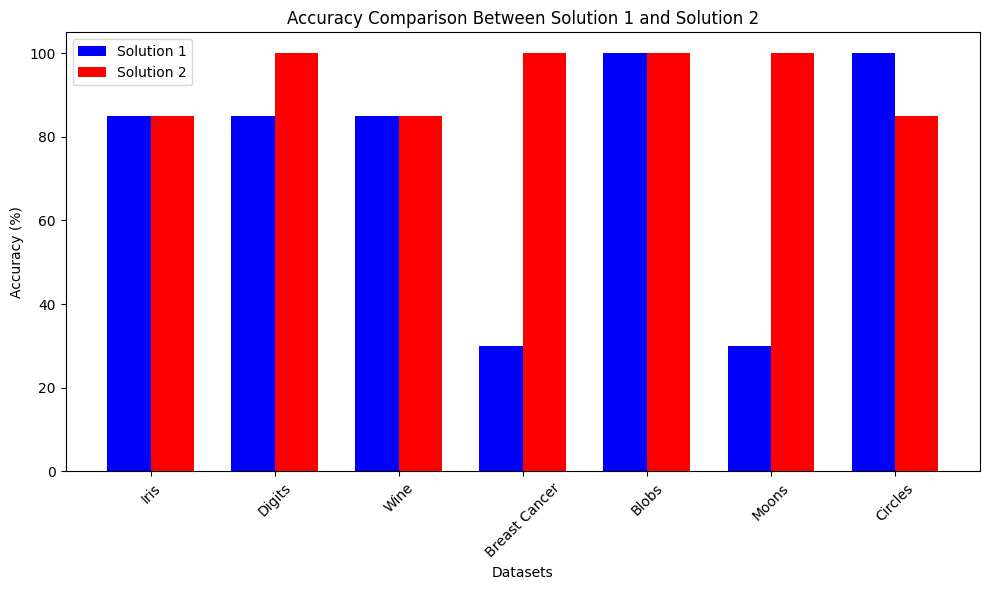

In [5]:
# Extract dataset names and accuracy values
datasets = [item[0] for item in similarities1]
accuracy1 = [item[3] for item in similarities1]
accuracy2 = [item[3] for item in similarities2]

# Plotting
x = range(len(datasets))  # X-axis positions

# Create the bar plot
plt.figure(figsize=(10, 6))
bar_width = 0.35
plt.bar(x, accuracy1, width=bar_width, label='Solution 1', color='b', align='center')
plt.bar([p + bar_width for p in x], accuracy2, width=bar_width, label='Solution 2', color='r', align='center')

# Labeling
plt.xlabel('Datasets')
plt.ylabel('Accuracy (%)')
plt.title('Accuracy Comparison Between Solution 1 and Solution 2')
plt.xticks([p + bar_width / 2 for p in x], datasets, rotation=45)
plt.legend()

# Display the plot
plt.tight_layout()
plt.show()


## ADDING CODE TO CALCULATE THE DISTANCES INTER AND INTRA OF THE CLASSIC K-MEANS VS MY SOLUTION AND PLOT THE RESULTS:

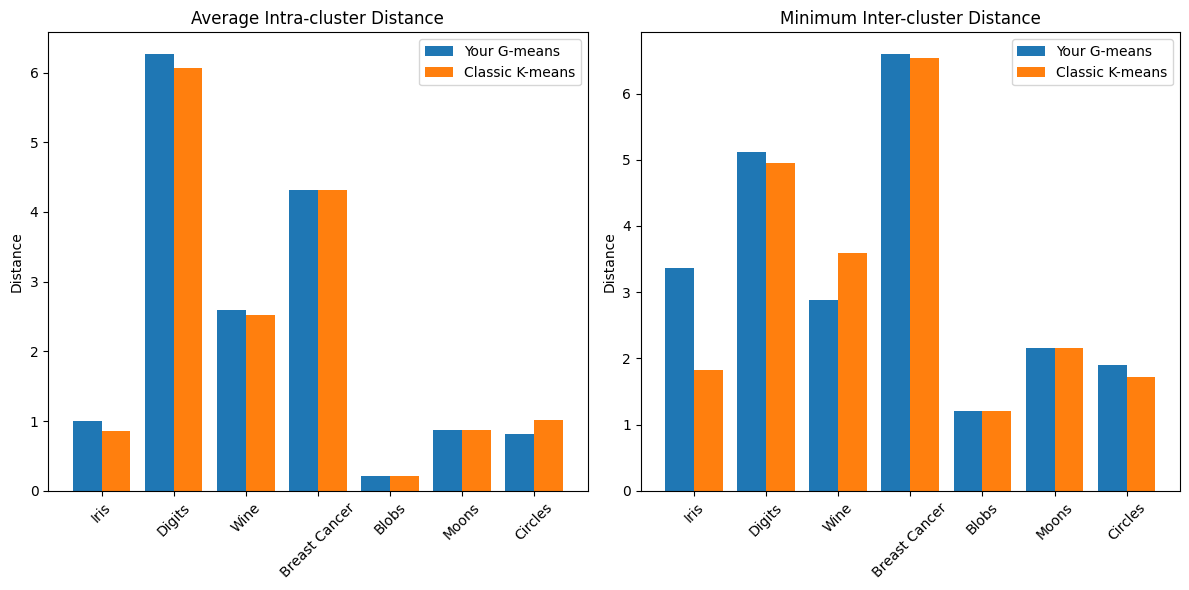


Detailed Results:

Dataset: Iris
True k: 3, Your predicted k: 2
Your method - Intra: 0.999, Inter: 3.366
Classic K-means - Intra: 0.861, Inter: 1.818

Dataset: Digits
True k: 10, Your predicted k: 13
Your method - Intra: 6.263, Inter: 5.121
Classic K-means - Intra: 6.067, Inter: 4.953

Dataset: Wine
True k: 3, Your predicted k: 4
Your method - Intra: 2.588, Inter: 2.885
Classic K-means - Intra: 2.523, Inter: 3.596

Dataset: Breast Cancer
True k: 2, Your predicted k: 2
Your method - Intra: 4.317, Inter: 6.594
Classic K-means - Intra: 4.320, Inter: 6.544

Dataset: Blobs
True k: 4, Your predicted k: 4
Your method - Intra: 0.214, Inter: 1.203
Classic K-means - Intra: 0.214, Inter: 1.203

Dataset: Moons
True k: 2, Your predicted k: 2
Your method - Intra: 0.872, Inter: 2.162
Classic K-means - Intra: 0.872, Inter: 2.162

Dataset: Circles
True k: 2, Your predicted k: 3
Your method - Intra: 0.811, Inter: 1.898
Classic K-means - Intra: 1.011, Inter: 1.720


In [7]:
import numpy as np
from sklearn.cluster import KMeans
from sklearn.metrics import pairwise_distances
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler

def calculate_cluster_metrics(X, labels, centroids):
    """Calculate intra and inter cluster distances"""
    # Intra-cluster distances (compactness)
    intra_dists = []
    for i in np.unique(labels):
        cluster_points = X[labels == i]
        centroid = centroids[i]
        dists = np.linalg.norm(cluster_points - centroid, axis=1)
        intra_dists.append(np.mean(dists))
    avg_intra = np.mean(intra_dists)
    
    # Inter-cluster distances (separation)
    inter_dists = pairwise_distances(centroids)
    np.fill_diagonal(inter_dists, np.inf)  # ignore distance to self
    min_inter = np.min(inter_dists)
    
    return avg_intra, min_inter

def evaluate_methods(datasets_list):
    results = {}
    
    for dataset in datasets_list:
        name = dataset[0]
        X = dataset[1][0]  # Extract data from tuple
        true_k = dataset[1][1]  # Extract true k from tuple
        
        # Standardize data
        X = StandardScaler().fit_transform(X)
        
        # Your G-means method
        your_k, _ = g_means(X)
        your_kmeans = KMeans(n_clusters=your_k, init='k-means++', n_init=1, random_state=42)
        your_labels = your_kmeans.fit_predict(X)
        your_intra, your_inter = calculate_cluster_metrics(X, your_labels, your_kmeans.cluster_centers_)
        
        # Classic K-means with random init
        classic_kmeans = KMeans(n_clusters=true_k, init='random', n_init=10, random_state=42)
        classic_labels = classic_kmeans.fit_predict(X)
        classic_intra, classic_inter = calculate_cluster_metrics(X, classic_labels, classic_kmeans.cluster_centers_)
        
        results[name] = {
            'your_intra': your_intra,
            'your_inter': your_inter,
            'classic_intra': classic_intra,
            'classic_inter': classic_inter,
            'your_k': your_k,
            'true_k': true_k
        }
    
    return results

def plot_results(results):
    datasets = list(results.keys())
    
    # Intra-cluster distance comparison
    plt.figure(figsize=(12, 6))
    plt.subplot(1, 2, 1)
    plt.bar(np.arange(len(datasets)) - 0.2, 
            [results[name]['your_intra'] for name in datasets], 
            width=0.4, label='Your G-means')
    plt.bar(np.arange(len(datasets)) + 0.2, 
            [results[name]['classic_intra'] for name in datasets], 
            width=0.4, label='Classic K-means')
    plt.xticks(np.arange(len(datasets)), datasets, rotation=45)
    plt.title('Average Intra-cluster Distance')
    plt.ylabel('Distance')
    plt.legend()
    
    # Inter-cluster distance comparison
    plt.subplot(1, 2, 2)
    plt.bar(np.arange(len(datasets)) - 0.2, 
            [results[name]['your_inter'] for name in datasets], 
            width=0.4, label='Your G-means')
    plt.bar(np.arange(len(datasets)) + 0.2, 
            [results[name]['classic_inter'] for name in datasets], 
            width=0.4, label='Classic K-means')
    plt.xticks(np.arange(len(datasets)), datasets, rotation=45)
    plt.title('Minimum Inter-cluster Distance')
    plt.ylabel('Distance')
    plt.legend()
    
    plt.tight_layout()
    plt.show()

# Convert your datasets to the correct format
datasets_list = [
    ("Iris", (load_iris().data, 3)),
    ("Digits", (load_digits().data, 10)),
    ("Wine", (load_wine().data, 3)),
    ("Breast Cancer", (load_breast_cancer().data, 2)),
    ("Blobs", (make_blobs(n_samples=300, centers=4, random_state=42)[0], 4)),
    ("Moons", (make_moons(n_samples=300, noise=0.05, random_state=42)[0], 2)),
    ("Circles", (make_circles(n_samples=300, noise=0.05, factor=0.5, random_state=42)[0], 2))
]

# Run evaluation
results = evaluate_methods(datasets_list)
plot_results(results)

# Print numerical results
print("\nDetailed Results:")
for name in results:
    print(f"\nDataset: {name}")
    print(f"True k: {results[name]['true_k']}, Your predicted k: {results[name]['your_k']}")
    print(f"Your method - Intra: {results[name]['your_intra']:.3f}, Inter: {results[name]['your_inter']:.3f}")
    print(f"Classic K-means - Intra: {results[name]['classic_intra']:.3f}, Inter: {results[name]['classic_inter']:.3f}")